# Support Vector Machine (SVM)
Support Vector Machines (SVM) zijn krachtige en veelzijdige algoritmen voor zowel classificatie- als regressietaken. Het belangrijkste idee achter SVM is het vinden van een hypervlak dat de gegevenspunten van verschillende klassen in de feature-ruimte scheidt met de grootste marge. Dit hypervlak wordt bepaald door de zogenaamde "support vectors", de gegevenspunten die het dichtst bij het hypervlak liggen. SVM kan ook worden uitgebreid naar niet-lineaire classificatie door gebruik te maken van kernel-tricks, die de gegevens in een hogere dimensionale ruimte projecteren waar een lineaire scheiding mogelijk is. SVM is bijzonder effectief bij hoge-dimensionale datasets en wordt vaak gebruikt in toepassingen zoals tekstclassificatie en beeldherkenning.

# Uitgebreide Support Vector Machine Analyse
Dit onderzoek evalueert SVM prestatie over verschillende configuraties:
- **Kernel Types**: Linear, RBF, Polynomial, Sigmoid kernels
- **Feature Representaties**: Original features, PCA-reduced, LDA-reduced
- **Hyperparameter Optimalisatie**: GridSearchCV voor optimale parameters
- **SVM-Specifieke Analyse**: Support vectors, decision boundaries, kernel performance
- **Interpreteerbaarheid**: Feature importance door kernel analyse en support vector examinatie

In [1]:
import sys
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
warnings.filterwarnings('ignore')

# Add the parent directory (project root) to Python path
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils.libs_generic_functions import LibsDataLoader, LibsDataPreprocessor
from utils.baseline_correction_functions import BaselineCorrector, analyze_correction_quality, print_quality_report
from utils.normalization_functions import Normalizer
from utils.pca_analysis_functions import PCAAnalyzer, quick_pca_analysis
from utils.lda_analysis_functions import quick_lda_analysis
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/csv/processed_data.csv")

In [3]:
Preprocessor = LibsDataPreprocessor()
X_train, X_test, y_train, y_test, label_encoder, wavelength_columns = Preprocessor.prepare_ml_data(df)

PREPARING DATA FOR MACHINE LEARNING
Original dataset shape: (51453, 8004)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Splitting complete dataset (test_size=0.2, random_state=42)...
Training dataset shape: (41162, 8004)
Test dataset shape: (10291, 8004)
Training target distribution:
origin
tread         14349
innerliner    13808
sidewall      13005
Name: count, dtype: int64
Test target distribution:
origin
tread         3587
innerliner    3452
sidewall      3252
Name: count, dtype: int64

Identified 8001 wavelength columns
Extracting features and targets from training set...
Extracting features and targets from test set...
Converting features to numeric...
Encoding labels...

Final results:
Training features shape: (41162, 8001)
Test features shape: (10291, 8001)
Label classes: ['innerliner' 'sidewall' 'tread']
Training label distribution: [13808 13005 14349]
Test label distribution: [3452 3252 3587]


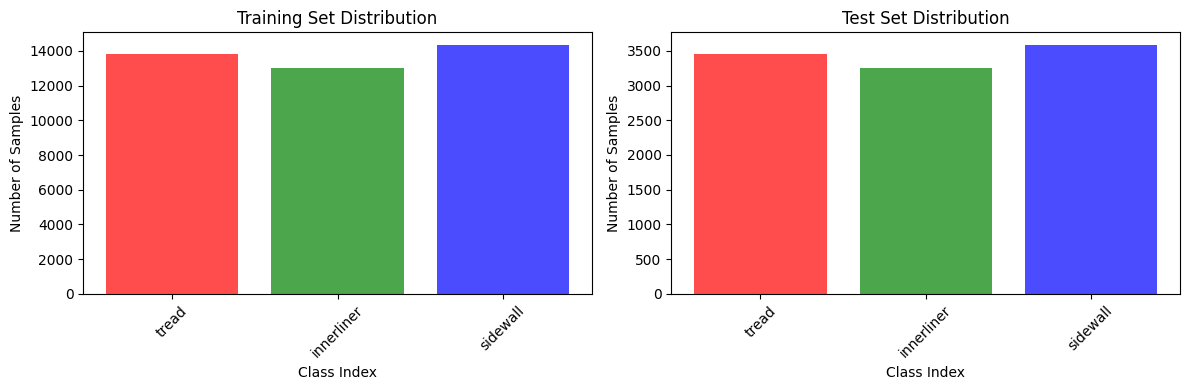

In [4]:
# Display train/test distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Training set distribution
train_unique, train_counts = np.unique(y_train, return_counts=True)
ax1.bar(range(len(train_unique)), train_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax1.set_title('Training Set Distribution')
ax1.set_xlabel('Class Index')
ax1.set_ylabel('Number of Samples')
ax1.set_xticks(range(len(train_unique)))
ax1.set_xticklabels(("tread", "innerliner", "sidewall"), rotation=45)

# Test set distribution  
test_unique, test_counts = np.unique(y_test, return_counts=True)
ax2.bar(range(len(test_unique)), test_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax2.set_title('Test Set Distribution')
ax2.set_xlabel('Class Index')
ax2.set_ylabel('Number of Samples')
ax2.set_xticks(range(len(test_unique)))
ax2.set_xticklabels(("tread", "innerliner", "sidewall"), rotation=45)

plt.tight_layout()
plt.show()

In [9]:
# Remove wavelengths from df that are not in NIST top 50% data
print("=" * 70)
print("FILTERING DF TO ONLY INCLUDE NIST TOP 50% WAVELENGTHS")
print("=" * 70)

# Load NIST top 50% wavelengths
nist_top_50_percent_df = pd.read_csv('../data/csv/nist_top_25_percent_wavelengths.csv')

# Extract all unique wavelengths from nist_top_50_percent_df
nist_wavelengths_set = set()
for column in nist_top_50_percent_df.columns:
    # Get wavelengths from this element column, drop NaN values
    element_wavelengths = nist_top_50_percent_df[column].dropna().tolist()
    nist_wavelengths_set.update([float(wl) for wl in element_wavelengths if pd.notna(wl)])

print(f"NIST wavelengths found: {len(nist_wavelengths_set)} unique wavelengths")
print(f"NIST wavelength range: {min(nist_wavelengths_set):.1f} - {max(nist_wavelengths_set):.1f} nm")

# Get wavelength columns from df (exclude metadata columns)
metadata_columns = ['tire_number', 'origin', 'measurement_id']
all_wavelength_columns = [col for col in df.columns if col not in metadata_columns]

print(f"\nOriginal df wavelengths: {len(all_wavelength_columns)}")
print(f"Original df wavelength range: {min([float(col) for col in all_wavelength_columns]):.1f} - {max([float(col) for col in all_wavelength_columns]):.1f} nm")

# Find wavelengths to keep (with tolerance for matching)
tolerance = 0.1  # 0.1 nm tolerance
wavelengths_to_keep = []

for col in all_wavelength_columns:
    col_wl = float(col)
    # Check if this wavelength is close to any NIST wavelength
    for nist_wl in nist_wavelengths_set:
        if abs(col_wl - nist_wl) <= tolerance:
            wavelengths_to_keep.append(col)
            break

print(f"\nWavelengths to keep: {len(wavelengths_to_keep)}")
print(f"Wavelengths to remove: {len(all_wavelength_columns) - len(wavelengths_to_keep)}")
print(f"Reduction: {((len(all_wavelength_columns) - len(wavelengths_to_keep)) / len(all_wavelength_columns)) * 100:.1f}%")

# Create filtered dataframe
columns_to_keep = metadata_columns + wavelengths_to_keep
df_filtered = df[columns_to_keep].copy()

print(f"\n✅ Filtered DataFrame created:")
print(f"   Original shape: {df.shape}")
print(f"   Filtered shape: {df_filtered.shape}")
print(f"   Columns removed: {df.shape[1] - df_filtered.shape[1]}")

# Show some examples of kept wavelengths
print(f"\nFirst 10 wavelengths kept:")
for i, wl in enumerate(wavelengths_to_keep[:10]):
    print(f"   {wl} nm")

if len(wavelengths_to_keep) > 10:
    print(f"   ... and {len(wavelengths_to_keep) - 10} more")

# Update the df variable to the filtered version
nist_filtered_df = df_filtered.copy()

print(f"\n🎯 df has been updated to only contain NIST top 50% wavelengths")
print(f"   New df shape: {nist_filtered_df.shape}")

FILTERING DF TO ONLY INCLUDE NIST TOP 50% WAVELENGTHS
NIST wavelengths found: 144 unique wavelengths
NIST wavelength range: 202.5 - 922.9 nm

Original df wavelengths: 8001
Original df wavelength range: 200.0 - 1000.0 nm

Wavelengths to keep: 163
Wavelengths to remove: 7838
Reduction: 98.0%

✅ Filtered DataFrame created:
   Original shape: (51453, 8004)
   Filtered shape: (51453, 166)
   Columns removed: 7838

First 10 wavelengths kept:
   202.4 nm
   202.5 nm
   202.6 nm
   202.7 nm
   212.3 nm
   212.4 nm
   212.5 nm
   237.1 nm
   237.2 nm
   237.3 nm
   ... and 153 more

🎯 df has been updated to only contain NIST top 50% wavelengths
   New df shape: (51453, 166)


In [11]:
nist_X_train, nist_X_test, nist_y_train_encoded, nist_y_test_encoded, label_encoder, wavelength_columns = Preprocessor.prepare_ml_data(nist_filtered_df) 

PREPARING DATA FOR MACHINE LEARNING
Original dataset shape: (51453, 166)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Splitting complete dataset (test_size=0.2, random_state=42)...
Training dataset shape: (41162, 166)
Test dataset shape: (10291, 166)
Training target distribution:
origin
tread         14349
innerliner    13808
sidewall      13005
Name: count, dtype: int64
Test target distribution:
origin
tread         3587
innerliner    3452
sidewall      3252
Name: count, dtype: int64

Identified 163 wavelength columns
Extracting features and targets from training set...
Extracting features and targets from test set...
Converting features to numeric...
Encoding labels...

Final results:
Training features shape: (41162, 163)
Test features shape: (10291, 163)
Label classes: ['innerliner' 'sidewall' 'tread']
Training label distribution: [13808 13005 14349]
Test label distribution: [3452 3252 3587]


In [7]:
# Convert column names to wavelengths and filter
wavelength_values = [float(col) for col in X_train.columns]
selected_indices = []
selected_wavelengths = []

for i, wl in enumerate(wavelength_values):
    if (670 <= wl <= 750) or (950 <= wl <= 960):
        selected_indices.append(i)
        selected_wavelengths.append(wl)

# Create filtered datasets from subset
X_train_ig = X_train.iloc[:, selected_indices]
X_test_ig = X_test.iloc[:, selected_indices]

## 1. SVM op originele features

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import time
import tracemalloc
import gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add the measure_model_details import
from utils.measure_model_details import (
    measure_training_time, measure_inference_time, get_memory_usage
)

def comprehensive_svm_evaluation():
    """
    Comprehensive SVM evaluation across 4 different feature sets:
    1. PCA reduced features
    2. LDA reduced features  
    3. Information Gain selected wavelengths
    4. NIST emission line selected features
    """
    
    print("=" * 80)
    print("COMPREHENSIVE SVM EVALUATION")
    print("=" * 80)
    
    # Initialize results storage
    evaluation_results = {}
    
    # Define comprehensive SVM configurations for different kernels
    svm_configs = {
        # 'linear': {
        #     'kernel': 'linear',
        #     'param_grid': {
        #         'C': [0.1, 1, 10]
        #     }
        # },
        'rbf': {
            'kernel': 'rbf', 
            'param_grid': {
                'C': [10],
                'gamma': [0.01]
            }
        },
        # 'poly': {
        #     'kernel': 'poly',
        #     'param_grid': {
        #         'C': [1, 10],
        #         'degree': [2, 3],
        #         'gamma': ['scale', 'auto']
        #     }
        # },
        # 'sigmoid': {
        #     'kernel': 'sigmoid',
        #     'param_grid': {
        #         'C': [1, 10],
        #         'gamma': ['scale', 'auto', 0.1]
        #     }
        # }
    }
    
    # print(f"Testing multiple SVM kernels:")
    # for kernel_name, config in svm_configs.items():
    #     grid_size = 1
    #     for param, values in config['param_grid'].items():
    #         grid_size *= len(values)
    #     print(f"   • {kernel_name.upper()}: {grid_size} parameter combinations")
    
    print(f"Cross-validation folds: 5")
    print()
    
    return svm_configs, evaluation_results

def evaluate_svm_configuration(X_train, X_test, y_train, y_test, 
                              config_name, svm_configs, label_encoder,
                              n_runs=3):
    """
    Evaluate a single SVM configuration with comprehensive metrics.
    
    Parameters:
    -----------
    X_train, X_test : array-like
        Training and test features
    y_train, y_test : array-like
        Training and test labels
    config_name : str
        Name of the configuration being tested
    svm_configs : dict
        SVM kernel configurations with parameter grids
    label_encoder : LabelEncoder
        Label encoder for classification reports
    n_runs : int, default=3
        Number of runs for timing measurements
        
    Returns:
    --------
    dict : Comprehensive evaluation results
    """
    
    print(f"\n{'='*60}")
    print(f"EVALUATING: {config_name.upper()}")
    print(f"{'='*60}")
    print(f"Training shape: {X_train.shape}")
    print(f"Test shape: {X_test.shape}")
    
    # Track memory usage
    tracemalloc.start()
    memory_before = get_memory_usage()
    
    # Cross-validation setup
    cv_folds = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    
    # 1. TEST ALL SVM KERNELS AND FIND BEST
    print(f"\n🔍 Testing SVM Kernels with Hyperparameter Optimization...")
    
    kernel_results = {}
    optimization_start = time.perf_counter()
    
    for kernel_name, config in svm_configs.items():
        print(f"   Testing {kernel_name.upper()} kernel...")
        
        try:
            # Create SVM with specific kernel
            svm = SVC(kernel=config['kernel'], random_state=42, probability=True)
            
            # Grid search for optimal parameters
            grid_search = GridSearchCV(
                svm, 
                config['param_grid'], 
                cv=cv_folds, 
                scoring='accuracy',
                n_jobs=-1,
                verbose=0
            )
            
            # Fit and evaluate
            grid_search.fit(X_train, y_train)
            
            # Test set performance
            test_accuracy = grid_search.score(X_test, y_test)
            
            # Store results
            result = {
                'best_score': grid_search.best_score_,
                'test_accuracy': test_accuracy,
                'best_params': grid_search.best_params_,
                'best_estimator': grid_search.best_estimator_,
                'n_support_vectors': grid_search.best_estimator_.n_support_.sum(),
                'support_vector_ratio': grid_search.best_estimator_.n_support_.sum() / len(X_train)
            }
            
            kernel_results[kernel_name] = result
            
            print(f"     CV score: {grid_search.best_score_:.4f}, Test: {test_accuracy:.4f}")
            print(f"     Best params: {grid_search.best_params_}")
            print(f"     Support vectors: {result['n_support_vectors']} ({result['support_vector_ratio']:.3f})")
            
        except Exception as e:
            print(f"     Error with {kernel_name}: {str(e)}")
            kernel_results[kernel_name] = {
                'error': str(e),
                'test_accuracy': 0,
                'best_score': 0
            }
    
    # Find best kernel
    best_kernel_name = max(kernel_results.keys(), 
                          key=lambda x: kernel_results[x].get('test_accuracy', 0))
    best_kernel_config = kernel_results[best_kernel_name]
    
    optimization_end = time.perf_counter()
    optimization_time = optimization_end - optimization_start
    
    print(f"\n🏆 Best kernel: {best_kernel_name.upper()}")
    print(f"   Test accuracy: {best_kernel_config['test_accuracy']:.4f}")
    print(f"   CV score: {best_kernel_config['best_score']:.4f}")
    print(f"   Best parameters: {best_kernel_config['best_params']}")
    print(f"   Total optimization time: {optimization_time:.2f} seconds")
    
    # 2. TRAINING TIME MEASUREMENT
    print(f"\n⏱️  Training Time Measurement ({n_runs} runs)...")
    
    # Get best model
    final_model = best_kernel_config['best_estimator']
    
    # Create new instance for clean timing measurement
    final_model_clean = SVC(**final_model.get_params())
    
    # Measure training time
    training_results = measure_training_time(
        final_model_clean, X_train, y_train, n_runs=n_runs
    )
    
    print(f"   Mean training time: {training_results['mean_time']:.4f} ± {training_results['std_time']:.4f} seconds")
    print(f"   Memory increase: {training_results['memory_increase_mean']:.2f} MB")
    
    # Use the trained model from timing measurement
    trained_model = training_results['trained_model']
    
    # 3. PREDICTION AND PERFORMANCE METRICS
    print(f"\n📊 Performance Evaluation...")
    
    # Make predictions
    y_train_pred = trained_model.predict(X_train)
    y_test_pred = trained_model.predict(X_test)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # F1 scores (macro and weighted)
    train_f1_macro = f1_score(y_train, y_train_pred, average='macro')
    test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
    train_f1_weighted = f1_score(y_train, y_train_pred, average='weighted')
    test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')
    
    print(f"   Training Accuracy: {train_accuracy:.4f}")
    print(f"   Test Accuracy: {test_accuracy:.4f}")
    print(f"   Training F1 (macro): {train_f1_macro:.4f}")
    print(f"   Test F1 (macro): {test_f1_macro:.4f}")
    print(f"   Training F1 (weighted): {train_f1_weighted:.4f}")
    print(f"   Test F1 (weighted): {test_f1_weighted:.4f}")
    
    # 4. INFERENCE TIME MEASUREMENT
    print(f"\n⚡ Inference Time Measurement...")
    
    inference_results = measure_inference_time(trained_model, X_test, n_runs=10)
    
    print(f"   Mean inference time: {inference_results['mean_time']*1000:.2f} ± {inference_results['std_time']*1000:.2f} ms")
    print(f"   Time per sample: {inference_results['mean_time']*1000/len(X_test):.4f} ms")
    print(f"   Samples per second: {len(X_test)/inference_results['mean_time']:.0f}")
    
    # 5. MEMORY USAGE ANALYSIS
    memory_after = get_memory_usage()
    memory_peak = tracemalloc.get_traced_memory()[1] / 1024 / 1024  # Convert to MB
    tracemalloc.stop()
    
    print(f"\n💾 Memory Usage Analysis...")
    print(f"   Memory before: {memory_before:.2f} MB")
    print(f"   Memory after: {memory_after:.2f} MB")
    print(f"   Memory increase: {memory_after - memory_before:.2f} MB")
    print(f"   Peak memory usage: {memory_peak:.2f} MB")
    
    # 6. SVM MODEL CHARACTERISTICS
    print(f"\n🎯 SVM Model Characteristics...")
    print(f"   Best kernel: {best_kernel_name.upper()}")
    print(f"   Number of classes: {len(trained_model.classes_)}")
    print(f"   Number of features: {X_train.shape[1]}")
    
    # Support vector analysis
    n_sv_total = trained_model.n_support_.sum()
    n_sv_per_class = trained_model.n_support_
    sv_ratio = n_sv_total / len(X_train)
    
    print(f"   Support vectors: {n_sv_total} ({sv_ratio:.3f} of training data)")
    print(f"   Support vectors per class: {dict(zip(label_encoder.classes_, n_sv_per_class))}")
    
    # Kernel-specific characteristics
    if best_kernel_name == 'linear':
        print(f"   Linear kernel: Direct interpretability, hyperplane separation")
        if hasattr(trained_model, 'coef_'):
            print(f"   Feature weights available for interpretation")
    elif best_kernel_name == 'rbf':
        print(f"   RBF kernel: Non-linear, Gaussian basis functions")
        print(f"   Gamma parameter: {trained_model.gamma}")
    elif best_kernel_name == 'poly':
        print(f"   Polynomial kernel: Degree {trained_model.degree}")
        print(f"   Gamma parameter: {trained_model.gamma}")
    elif best_kernel_name == 'sigmoid':
        print(f"   Sigmoid kernel: Neural network-like")
        print(f"   Gamma parameter: {trained_model.gamma}")
    
    print(f"   C parameter (regularization): {trained_model.C}")
    
    # Model complexity estimation
    model_memory_estimate = (n_sv_total * X_train.shape[1] * 8) / (1024 * 1024)  # 8 bytes per float64
    print(f"   Estimated model size: {model_memory_estimate:.2f} MB")
    
    # 7. DECISION FUNCTION ANALYSIS
    print(f"\n🎲 Decision Function Analysis...")
    
    # Get decision function values and prediction probabilities
    decision_values = trained_model.decision_function(X_test)
    y_pred_proba = trained_model.predict_proba(X_test)
    
    # Calculate decision confidence metrics
    if len(label_encoder.classes_) == 2:
        # Binary classification
        margin_distances = np.abs(decision_values)
    else:
        # Multi-class classification (one-vs-one)
        margin_distances = np.abs(decision_values).mean(axis=1)
    
    confidence_scores = np.max(y_pred_proba, axis=1)
    
    print(f"   Mean margin distance: {margin_distances.mean():.4f}")
    print(f"   Margin std deviation: {margin_distances.std():.4f}")
    print(f"   Mean prediction confidence: {confidence_scores.mean():.4f}")
    print(f"   Confidence std deviation: {confidence_scores.std():.4f}")
    print(f"   High confidence predictions (>0.9): {np.sum(confidence_scores > 0.9)}/{len(confidence_scores)} ({100*np.sum(confidence_scores > 0.9)/len(confidence_scores):.1f}%)")
    
    # 8. CLASSIFICATION REPORT
    print(f"\n📋 Classification Report:")
    print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, digits=4))
    
    # 9. CONFUSION MATRIX VISUALIZATION
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix - {config_name} ({best_kernel_name.upper()} kernel)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    
    # 10. KERNEL COMPARISON VISUALIZATION
    print(f"\n📈 SVM Kernels Performance Comparison...")
    
    # Test all kernels on test data for comparison
    kernel_test_scores = {}
    kernel_sv_ratios = {}
    for kernel_name, config in kernel_results.items():
        if 'test_accuracy' in config:
            kernel_test_scores[kernel_name] = config['test_accuracy']
            kernel_sv_ratios[kernel_name] = config.get('support_vector_ratio', 0)
            print(f"   {kernel_name.upper()}: Accuracy={config['test_accuracy']:.4f}, SVs={config.get('support_vector_ratio', 0):.3f}")
    
    # Plot kernel comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy comparison
    kernels = list(kernel_test_scores.keys())
    scores = list(kernel_test_scores.values())
    colors = ['lightblue', 'lightgreen', 'orange', 'pink'][:len(kernels)]
    
    bars1 = ax1.bar(kernels, scores, color=colors, alpha=0.7)
    ax1.set_title(f'SVM Kernels Performance - {config_name}')
    ax1.set_ylabel('Test Accuracy')
    ax1.set_xlabel('Kernel Type')
    ax1.set_ylim(0, 1.1)
    
    # Highlight best kernel
    best_idx = kernels.index(best_kernel_name)
    bars1[best_idx].set_color('red')
    bars1[best_idx].set_alpha(1.0)
    
    for bar, score in zip(bars1, scores):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # Support vector ratio comparison
    sv_ratios = list(kernel_sv_ratios.values())
    bars2 = ax2.bar(kernels, sv_ratios, color=colors, alpha=0.7)
    ax2.set_title(f'Support Vector Ratios - {config_name}')
    ax2.set_ylabel('Support Vector Ratio')
    ax2.set_xlabel('Kernel Type')
    
    # Highlight best kernel
    bars2[best_idx].set_color('red')
    bars2[best_idx].set_alpha(1.0)
    
    for bar, ratio in zip(bars2, sv_ratios):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{ratio:.3f}', ha='center', va='bottom', fontweight='bold')
    
    ax1.grid(axis='y', alpha=0.3)
    ax2.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Compile all results
    results = {
        'config_name': config_name,
        'data_shape': X_train.shape,
        'n_features': X_train.shape[1],
        
        # Best kernel results
        'best_kernel': best_kernel_name,
        'best_params': best_kernel_config['best_params'],
        'best_cv_score': best_kernel_config['best_score'],
        'optimization_time': optimization_time,
        'all_kernel_scores': kernel_test_scores,
        
        # Performance metrics
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'train_f1_macro': train_f1_macro,
        'test_f1_macro': test_f1_macro,
        'train_f1_weighted': train_f1_weighted,
        'test_f1_weighted': test_f1_weighted,
        
        # Timing results
        'training_time_mean': training_results['mean_time'],
        'training_time_std': training_results['std_time'],
        'inference_time_mean': inference_results['mean_time'],
        'inference_time_std': inference_results['std_time'],
        'inference_time_per_sample': inference_results['mean_time'] / len(X_test),
        'samples_per_second': len(X_test) / inference_results['mean_time'],
        
        # Memory results
        'memory_before': memory_before,
        'memory_after': memory_after,
        'memory_increase': memory_after - memory_before,
        'memory_peak': memory_peak,
        'training_memory_increase': training_results['memory_increase_mean'],
        'model_memory_estimate': model_memory_estimate,
        
        # SVM-specific characteristics
        'n_support_vectors': n_sv_total,
        'support_vector_ratio': sv_ratio,
        'support_vectors_per_class': dict(zip(label_encoder.classes_, n_sv_per_class)),
        'mean_margin_distance': margin_distances.mean(),
        'margin_std': margin_distances.std(),
        'mean_confidence': confidence_scores.mean(),
        'confidence_std': confidence_scores.std(),
        'high_confidence_ratio': np.sum(confidence_scores > 0.9) / len(confidence_scores),
        'C_parameter': trained_model.C,
        'kernel_params': {k: getattr(trained_model, k, None) for k in ['gamma', 'degree', 'coef0']},
        
        # Model object
        'trained_model': trained_model,
        'predictions': y_test_pred,
        'prediction_probabilities': y_pred_proba,
        'decision_values': decision_values
    }
    
    # Clean up memory
    gc.collect()
    
    return results

# Now run the comprehensive evaluation
svm_configs, evaluation_results = comprehensive_svm_evaluation()

COMPREHENSIVE SVM EVALUATION
Testing multiple SVM kernels:
   • RBF: 1 parameter combinations
Cross-validation folds: 5




🚀 Starting Test 1: NIST Emission Line Features

EVALUATING: NIST EMISSION LINES
Training shape: (41162, 163)
Test shape: (10291, 163)

🔍 Testing SVM Kernels with Hyperparameter Optimization...
   Testing RBF kernel...
     CV score: 0.7031, Test: 0.7086
     Best params: {'C': 10, 'gamma': 0.01}
     Support vectors: 27675 (0.672)

🏆 Best kernel: RBF
   Test accuracy: 0.7086
   CV score: 0.7031
   Best parameters: {'C': 10, 'gamma': 0.01}
   Total optimization time: 2114.26 seconds

⏱️  Training Time Measurement (3 runs)...
   Mean training time: 1522.1312 ± 24.4392 seconds
   Memory increase: -190.01 MB

📊 Performance Evaluation...
   Training Accuracy: 0.7172
   Test Accuracy: 0.7086
   Training F1 (macro): 0.7132
   Test F1 (macro): 0.7048
   Training F1 (weighted): 0.7146
   Test F1 (weighted): 0.7062

⚡ Inference Time Measurement...
   Mean inference time: 50582.18 ± 850.96 ms
   Time per sample: 4.9152 ms
   Samples per second: 203

💾 Memory Usage Analysis...
   Memory before: 4

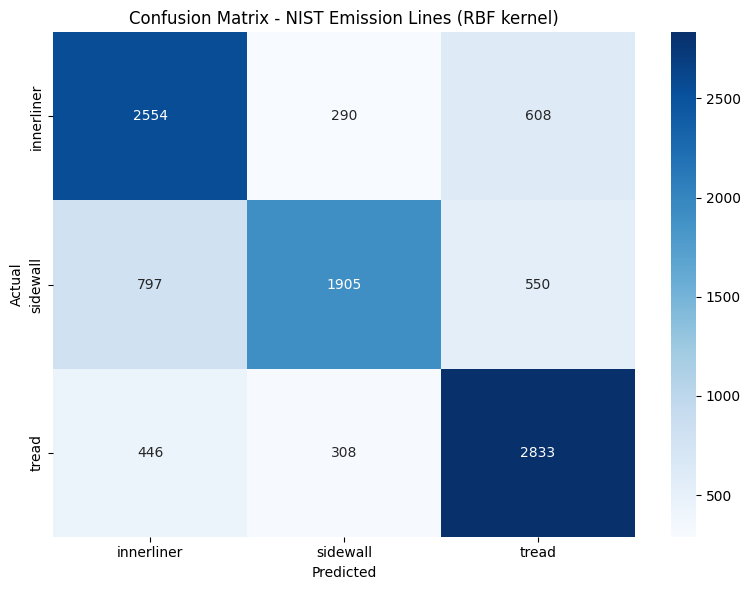


📈 SVM Kernels Performance Comparison...
   RBF: Accuracy=0.7086, SVs=0.672


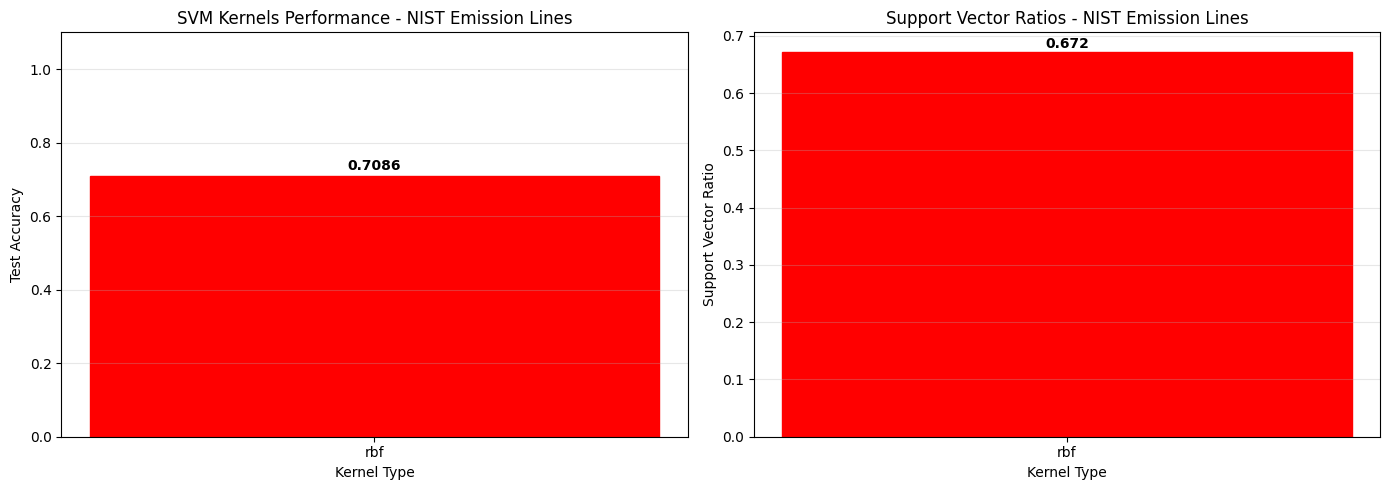

In [12]:
#Test 1: NIST Emission Line Features
print("\n🚀 Starting Test 1: NIST Emission Line Features")
nist_results = evaluate_svm_configuration(
    nist_X_train, nist_X_test, nist_y_train_encoded, nist_y_test_encoded,
    "NIST Emission Lines", svm_configs, label_encoder
)
evaluation_results['NIST'] = nist_results


🚀 Starting Test 2: Information Gain Selected Features

EVALUATING: INFORMATION GAIN SELECTION
Training shape: (41162, 902)
Test shape: (10291, 902)

🔍 Testing SVM Kernels with Hyperparameter Optimization...
   Testing RBF kernel...
     CV score: 0.9552, Test: 0.9672
     Best params: {'C': 10, 'gamma': 0.01}
     Support vectors: 10130 (0.246)

🏆 Best kernel: RBF
   Test accuracy: 0.9672
   CV score: 0.9552
   Best parameters: {'C': 10, 'gamma': 0.01}
   Total optimization time: 10383.04 seconds

⏱️  Training Time Measurement (3 runs)...
   Mean training time: 1926.8692 ± 4.0343 seconds
   Memory increase: 24.89 MB

📊 Performance Evaluation...
   Training Accuracy: 0.9919
   Test Accuracy: 0.9672
   Training F1 (macro): 0.9919
   Test F1 (macro): 0.9670
   Training F1 (weighted): 0.9919
   Test F1 (weighted): 0.9672

⚡ Inference Time Measurement...
   Mean inference time: 67105.54 ± 622.17 ms
   Time per sample: 6.5208 ms
   Samples per second: 153

💾 Memory Usage Analysis...
   Memo

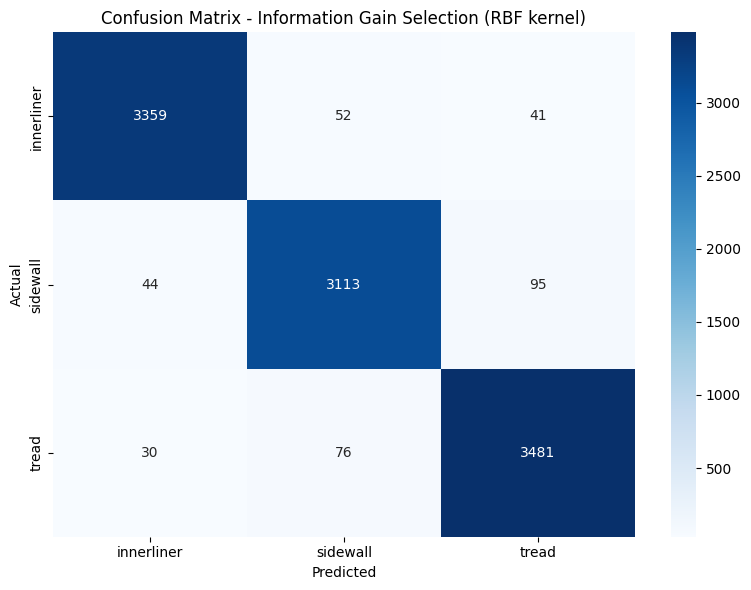


📈 SVM Kernels Performance Comparison...
   RBF: Accuracy=0.9672, SVs=0.246


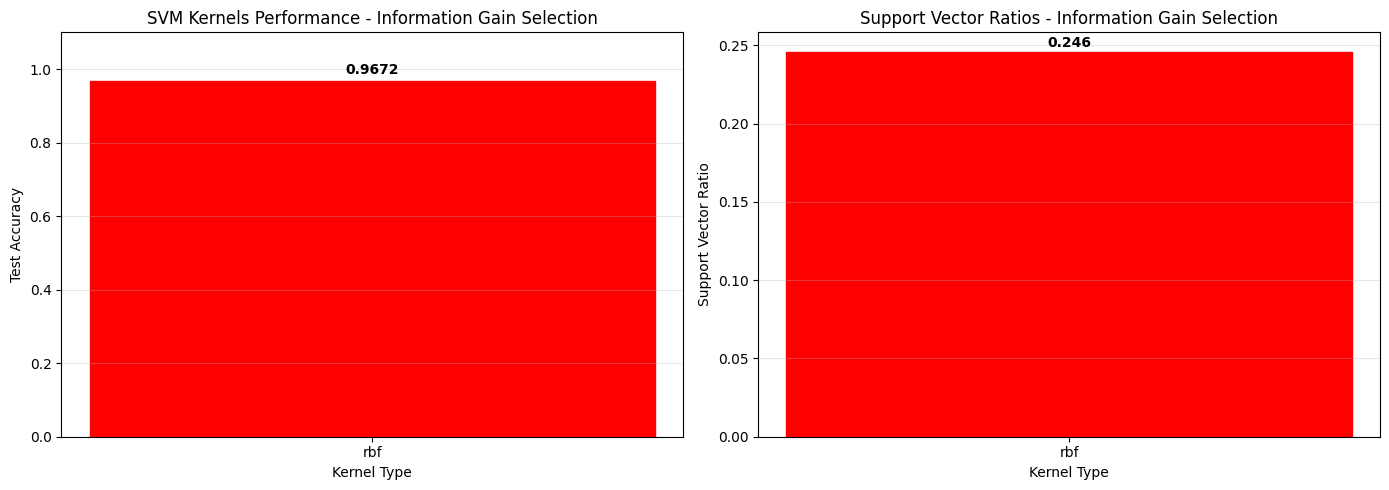

In [10]:
# Test 2: Information Gain Selected Features  
print("\n🚀 Starting Test 2: Information Gain Selected Features")
ig_results = evaluate_svm_configuration(
    X_train_ig, X_test_ig, y_train, y_test,
    "Information Gain Selection", svm_configs, label_encoder
)
evaluation_results['Information_Gain'] = ig_results


🚀 Starting Test 3: PCA Analysis

EVALUATING: PCA
Training shape: (41162, 18)
Test shape: (10291, 18)

🔍 Testing SVM Kernels with Hyperparameter Optimization...
   Testing RBF kernel...
     CV score: 0.9564, Test: 0.9709
     Best params: {'C': 10, 'gamma': 0.01}
     Support vectors: 13885 (0.337)

🏆 Best kernel: RBF
   Test accuracy: 0.9709
   CV score: 0.9564
   Best parameters: {'C': 10, 'gamma': 0.01}
   Total optimization time: 1911.19 seconds

⏱️  Training Time Measurement (3 runs)...
   Mean training time: 603.3552 ± 1.4676 seconds
   Memory increase: 1.40 MB

📊 Performance Evaluation...
   Training Accuracy: 0.9995
   Test Accuracy: 0.9709
   Training F1 (macro): 0.9995
   Test F1 (macro): 0.9708
   Training F1 (weighted): 0.9995
   Test F1 (weighted): 0.9710

⚡ Inference Time Measurement...
   Mean inference time: 14240.36 ± 159.14 ms
   Time per sample: 1.3838 ms
   Samples per second: 723

💾 Memory Usage Analysis...
   Memory before: 3589.30 MB
   Memory after: 1030.53 MB


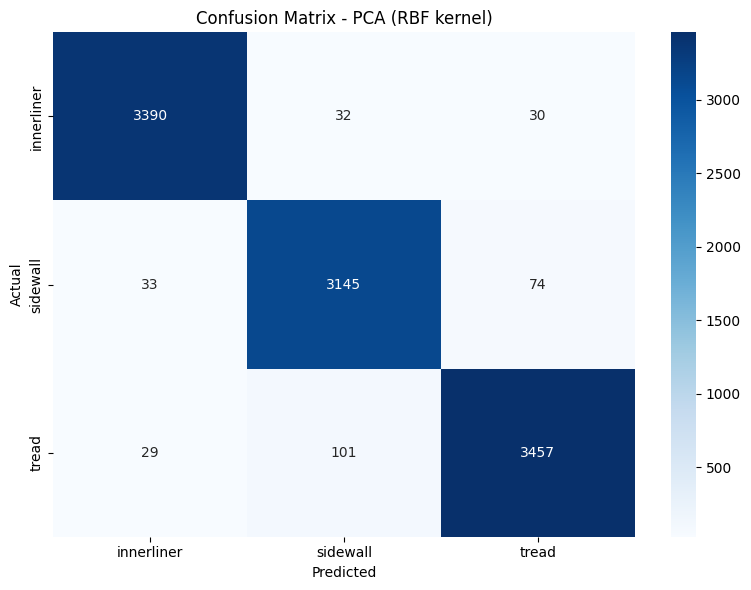


📈 SVM Kernels Performance Comparison...
   RBF: Accuracy=0.9709, SVs=0.337


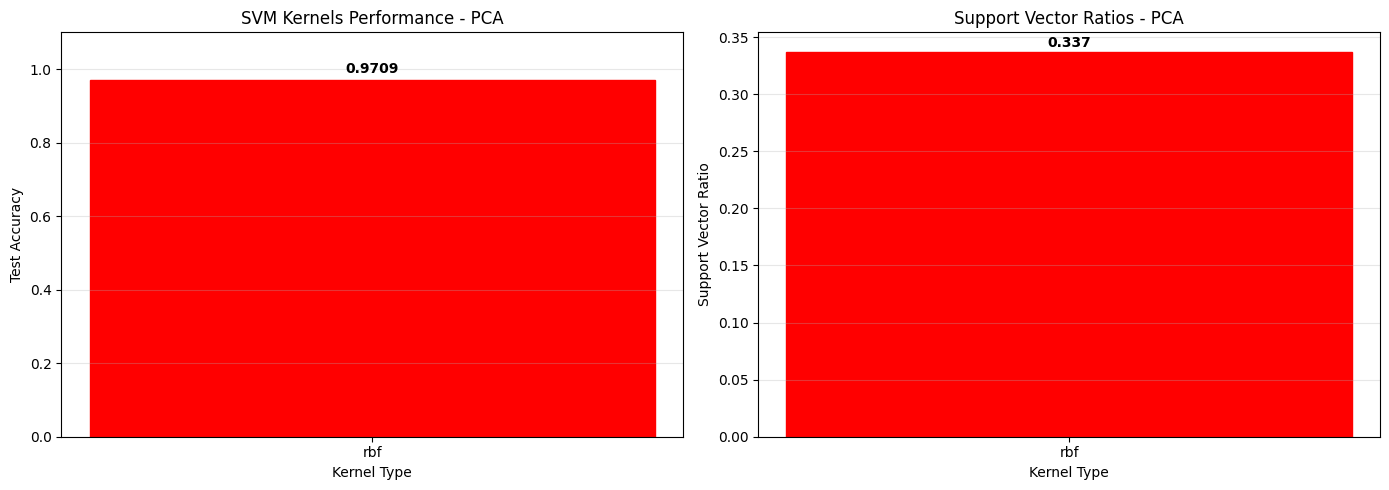

In [10]:
print("\n🚀 Starting Test 3: PCA Analysis")

# Apply PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=18) # n_components chosen based on prior analysis (95% variance)
X_train_pca = pca.fit_transform(X_train, y_train)
X_test_pca = pca.transform(X_test)

pca_result = evaluate_svm_configuration(
    X_train_pca, X_test_pca, y_train, y_test,
    config_name='PCA', svm_configs=svm_configs, label_encoder=label_encoder)


EVALUATING: LDA
Training shape: (41162, 2)
Test shape: (10291, 2)

🔍 Testing SVM Kernels with Hyperparameter Optimization...
   Testing RBF kernel...
     CV score: 0.9779, Test: 0.9262
     Best params: {'C': 10, 'gamma': 0.01}
     Support vectors: 2343 (0.057)

🏆 Best kernel: RBF
   Test accuracy: 0.9262
   CV score: 0.9779
   Best parameters: {'C': 10, 'gamma': 0.01}
   Total optimization time: 71.34 seconds

⏱️  Training Time Measurement (3 runs)...
   Mean training time: 25.5785 ± 0.3092 seconds
   Memory increase: 9.15 MB

📊 Performance Evaluation...
   Training Accuracy: 0.9779
   Test Accuracy: 0.9262
   Training F1 (macro): 0.9778
   Test F1 (macro): 0.9257
   Training F1 (weighted): 0.9779
   Test F1 (weighted): 0.9261

⚡ Inference Time Measurement...
   Mean inference time: 2265.47 ± 119.02 ms
   Time per sample: 0.2201 ms
   Samples per second: 4543

💾 Memory Usage Analysis...
   Memory before: 3364.68 MB
   Memory after: 3463.48 MB
   Memory increase: 98.80 MB
   Peak me

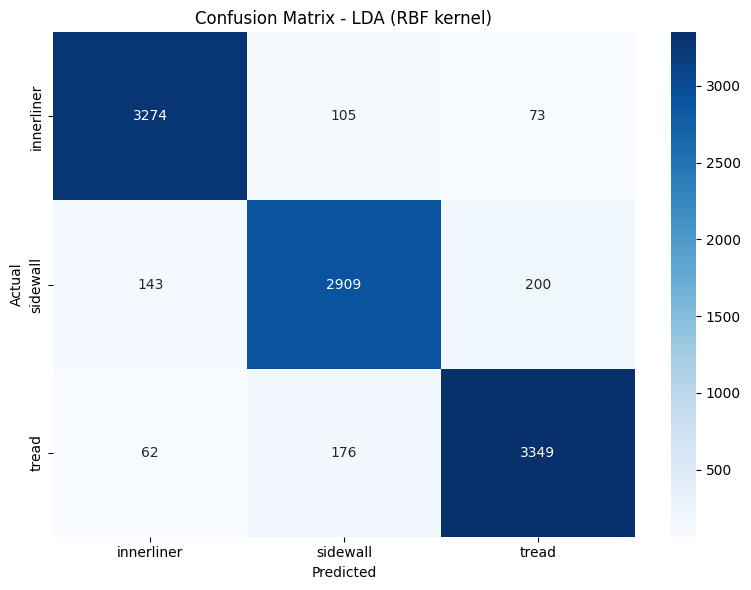


📈 SVM Kernels Performance Comparison...
   RBF: Accuracy=0.9262, SVs=0.057


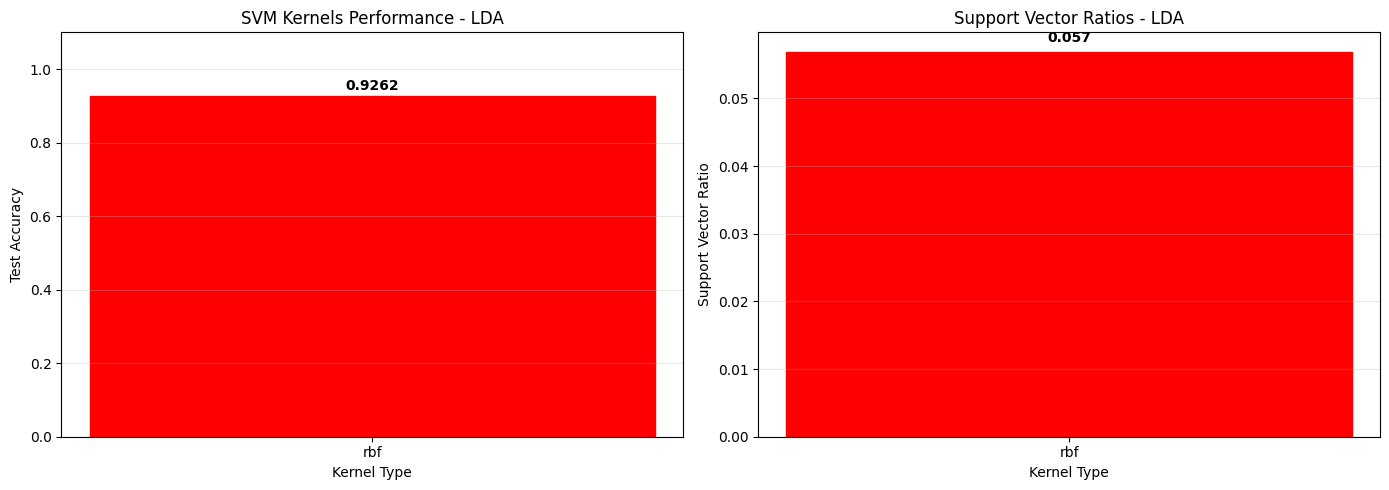

In [9]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=2)  # n_components chosen based on prior analysis

X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

lda_result = evaluate_svm_configuration(
	X_train_lda, X_test_lda, y_train, y_test,
	config_name="LDA", svm_configs=svm_configs, label_encoder=label_encoder
)

In [ ]:
# Comprehensive Results Comparison
print("=" * 80)
print("COMPREHENSIVE SVM RESULTS COMPARISON")
print("=" * 80)

# Extract results from PCA and LDA analyses
try:
    evaluation_results['PCA'] = {
        'config_name': f'PCA (18 components)',
        'test_accuracy': pca_result['test_f1_weighted'],
        'n_features': 18,
        'training_time_mean': pca_result['training_time_mean'],
        'inference_time_per_sample': pca_result['inference_time_per_sample'],
        'memory_peak': pca_result['memory_peak'],
    }
except:
    print("⚠️  Could not extract PCA results")

try:
        evaluation_results['LDA'] = {
            'config_name': f'LDA (2 components)',
            'test_accuracy': lda_result['test_f1_weighted'],
            'n_features': 2,
            'training_time_mean': lda_result['training_time_mean'],
            'inference_time_per_sample': lda_result['inference_time_per_sample'],
            'memory_peak': lda_result['memory_peak'],
        }
except:
    print("⚠️  Could not extract LDA results")

# Create summary table
summary_data = []
for method_name, results in evaluation_results.items():
    if isinstance(results, dict) and 'test_accuracy' in results:
        summary_data.append({
            'Method': results.get('config_name', method_name),
            'Test_Accuracy': results['test_accuracy'],
            'Features': results['n_features'],
            'training_time_mean': results.get('training_time_mean', 'N/A'),
            'inference_time_per_sample': results.get('inference_time_per_sample', 'N/A'),
            'memory_peak': results.get('memory_peak', 'N/A'),
        })

if summary_data:
    results_df = pd.DataFrame(summary_data)
    print("\SVM PERFORMANCE SUMMARY:")
    print("=" * 120)
    print(results_df.to_string(index=False))
    print("=" * 120)
    
    # Visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    methods = results_df['Method']
    accuracies = results_df['Test_Accuracy']
    features = results_df['Features']
    
    # 1. Accuracy comparison
    colors = ['skyblue', 'lightgreen', 'orange', 'pink'][:len(methods)]
    bars1 = ax1.bar(methods, accuracies, color=colors, alpha=0.7)
    ax1.set_title('Support Vector Machine Classification Accuracy Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Test Accuracy')
    ax1.set_ylim(0, 1.1)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)
    
    for bar, accuracy in zip(bars1, accuracies):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Feature count comparison
    bars2 = ax2.bar(methods, features, color=colors, alpha=0.7)
    ax2.set_title('Number of Features Used', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Number of Features')
    ax2.set_yscale('log')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(axis='y', alpha=0.3)
    
    for bar, feature_count in zip(bars2, features):
        ax2.text(bar.get_x() + bar.get_width()/2, feature_count * 1.2,
                 f'{feature_count}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Training time comparison (if available)
    training_times = [results_df['training_time_mean'].iloc[i] if results_df['training_time_mean'].iloc[i] != 'N/A' else 0 
                     for i in range(len(methods))]
    if any(t > 0 for t in training_times):
        bars3 = ax3.bar(methods, training_times, color=colors, alpha=0.7)
        ax3.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
        ax3.set_ylabel('Training Time (seconds)')
        ax3.tick_params(axis='x', rotation=45)
        ax3.grid(axis='y', alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'Training time data\nnot available', 
                transform=ax3.transAxes, ha='center', va='center', fontsize=12)
        ax3.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
    
    # 4. Memory usage comparison (if available)
    memory_usage = [results_df['memory_peak'].iloc[i] if results_df['memory_peak'].iloc[i] != 'N/A' else 0 
                   for i in range(len(methods))]
    if any(m > 0 for m in memory_usage):
        bars4 = ax4.bar(methods, memory_usage, color=colors, alpha=0.7)
        ax4.set_title('Memory Usage Comparison', fontsize=14, fontweight='bold')
        ax4.set_ylabel('Memory Increase (MB)')
        ax4.tick_params(axis='x', rotation=45)
        ax4.grid(axis='y', alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Memory usage data\nnot available', 
                transform=ax4.transAxes, ha='center', va='center', fontsize=12)
        ax4.set_title('Memory Usage Comparison', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()